# TECH CHALLENGE FASE 1 - EDA

Entendimento do negócio

● **Qual problema de negócio está sendo resolvido?**

A reatividade operacional, ou seja, a empresa perde clientes e dinheiro porque só descobre a insatisfação quando o dano (churn) já é iminente ou irreversível.


● **Por que o NPS é importante para um e-commerce?**

O NPS é importante para medir a satisfação do cliente, fazer com que ele volte a comprar no e-commerce e ainda seja um promotor da empresa, ou seja, indicando aquele e-commerce para outras pessoas. Além disso, é financeiramente mais barato recuperar um "Neutro” do que um "Detrator que teve um produto entregue com atraso por exemplo

● **Quais áreas poderiam se beneficiar desses insights? **

Correlacionando as variáveis que temos nos nossos dados, podemos entender onde as falhas estão acontecendo.
Por exemplo:
Teve estoque? Se faltou, a área de compras não poderia ter uma previsibilidade melhor de demandas?
Teve atraso? A área de logística, não poderia ter melhor planejamento nas entregas?
Teve problemas e o atendimento foi demorado? Podemos tentar antecipar problemas e ter um contato proativo do time de atendimento.


**Passo 1:** Import do arquivo desafio_nps_fase_1.csv 



In [ ]:
%pip install -r ~/postech/1IAST-TechChallenge/requirements.txt

In [ ]:
#Libs que serão utilizadas no projeto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
import os

# Define o caminho da pasta onde seu projeto está
path = "/home/vanessahay/postech/1IAST-TechChallenge/Notebook"

# Muda para essa pasta
os.chdir(path)

# Confirma se agora está certo
print(f"Diretório atual: {os.getcwd()}")

In [ ]:
# Carregamento de dados utilizando a biblioteca pandas
df_full_nps = pd.read_csv('../Data/desafio_nps_fase_1.csv', sep=None, engine='python')
df_full_nps.head()


print("Quantidade de linhas e colunas do dataframe:")
print(df_full_nps.shape)




In [ ]:
print("Tipos de cada coluna")
print(df_full_nps.dtypes)

In [ ]:
print("Valores nulos")
df_full_nps.isnull().sum()

In [ ]:
print("Colunas carregadas no dataframe")
df_full_nps.columns

In [ ]:
print("Resumo estatístico do dataframe")
df_full_nps.describe().round(2)

Análise Detalhada dos Perfis de NPS
Com base na tabela result gerada, podemos observar as seguintes características e padrões para cada perfil de NPS:

1. Detratores (nps_score <= 6)

total_clientes: Representam a maior parte da base de clientes (2109), o que é preocupante, pois são clientes insatisfeitos.
total_recompras_30d: 0. Isso indica que nenhum dos clientes detratores realizou uma recompra nos últimos 30 dias, confirmando sua baixa ou inexistente fidelidade.
taxa_recompra_percent: 0.0%, diretamente ligada ao total_recompras_30d.
tempo_medio_relacionamento_meses: 61.4 meses. Embora o tempo médio de relacionamento seja significativo, a insatisfação atual pode comprometer a longevidade desses clientes.
media_atraso_entrega: 2.41 dias. Este é o maior atraso médio de entrega entre todos os perfis, sugerindo uma forte correlação entre atrasos e insatisfação.
media_contatos_suporte: 1.63 contatos. É o maior número médio de contatos com o suporte, indicando que esses clientes têm mais problemas e precisam de mais assistência.
total_reclamacoes: 9369. O número total de reclamações para este grupo é extremamente alto, reforçando a profundidade da insatisfação.
Conclusão para Detratores: São clientes altamente insatisfeitos, que não recompram, sofrem com atrasos significativos na entrega, necessitam de mais contato com o suporte e geram um volume muito alto de reclamações. A reatividade operacional mencionada no entendimento do negócio é mais evidente neste grupo.

2. Neutros (7 <= nps_score <= 8)

total_clientes: 281 clientes. Um grupo menor que os detratores, mas ainda relevante.
total_recompras_30d: 108 recompras. Há uma taxa de recompra significativa, indicando que, embora não sejam entusiastas, ainda realizam compras repetidas.
taxa_recompra_percent: 38.43%. Uma taxa razoável, mas com potencial de melhoria para se tornarem promotores.
tempo_medio_relacionamento_meses: 59.8 meses. Similar aos detratores, o que sugere que o tempo de relacionamento por si só não garante a satisfação.
media_atraso_entrega: 1.05 dias. O atraso médio é consideravelmente menor que o dos detratores, mas ainda presente.
media_contatos_suporte: 1.01 contatos. Menos contatos com o suporte do que os detratores, mas mais do que os promotores.
total_reclamacoes: 757. Um número substancialmente menor de reclamações comparado aos detratores, mas ainda indica pontos de atrito.
Conclusão para Neutros: São clientes com potencial. Embora não sejam insatisfeitos a ponto de se tornarem detratores, suas experiências não são consistentes o suficiente para convertê-los em promotores. Ações direcionadas podem transformar esses clientes em promotores, especialmente focando na redução dos pequenos atrasos e otimização do atendimento.

3. Promotores (nps_score >= 9)

total_clientes: 110 clientes. O menor grupo, mas o mais valioso em termos de fidelidade e recomendação.
total_recompras_30d: 110 recompras. Todos os promotores realizaram uma recompra nos últimos 30 dias.
taxa_recompra_percent: 100.0%. Esta é a métrica mais impressionante, mostrando total fidelidade.
tempo_medio_relacionamento_meses: 63.0 meses. Um tempo de relacionamento robusto, um pouco maior que os outros grupos.
media_atraso_entrega: 0.72 dias. O menor atraso médio de entrega, indicando que a pontualidade é um fator chave para a satisfação.
media_contatos_suporte: 0.67 contatos. O menor número médio de contatos com o suporte, refletindo experiências positivas e poucos problemas.
total_reclamacoes: 250. O menor número total de reclamações, o que é esperado para clientes altamente satisfeitos.
Conclusão para Promotores: São os clientes ideais: fiéis, recompram ativamente, têm as melhores experiências de entrega e quase não precisam de suporte. Eles são os defensores da marca e a base para o crescimento orgânico através de indicações.

Padrões Observados e Contribuição para a Classificação NPS:
Atraso na Entrega (media_atraso_entrega): Há uma correlação inversa clara. Quanto maior o atraso na entrega, maior a probabilidade de ser um detrator. Atrasos mínimos estão associados a promotores.
Contatos com o Suporte (media_contatos_suporte): Similar ao atraso, um maior número de contatos com o serviço de atendimento ao cliente está associado a detratores, indicando que a necessidade de interação com o suporte geralmente surge de problemas não resolvidos ou inconvenientes.
Reclamações (total_reclamacoes): O volume de reclamações é um indicador direto da insatisfação. Detratores geram significativamente mais reclamações do que neutros e promotores, com promotores tendo um volume muito baixo.
Taxa de Recompra (taxa_recompra_percent): Reflete a lealdade e satisfação. Promotores têm uma taxa de recompra de 100%, neutros têm uma taxa moderada, e detratores não realizam recompras, evidenciando o impacto negativo da insatisfação no comportamento de compra futuro.


**Passo 2** Criação das variáveis de negócio

O NPS (Net Promoter Score) é uma métrica de fidelidade e satisfação do cliente que avalia a probabilidade de recomendação de uma empresa, produto ou serviço, numa escala de 0 a 10. Ele classifica clientes em promotores (9-10), neutros (7-8) ou detratores (0-6), ajudando a identificar a saúde do negócio e oportunidades de melhoria.

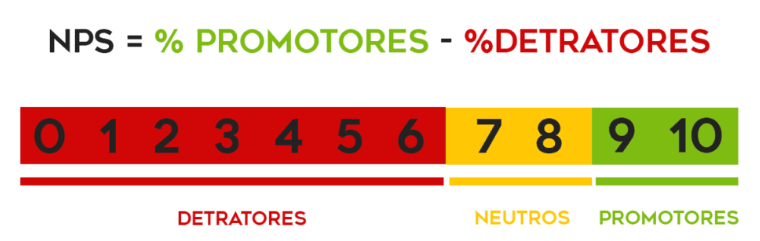




In [ ]:
# A funçao categorizar_nps classifica cada cliente da base de acordo
#  com a métrica oficial.

def categorizar_nps(df):
    """Categoriza o NPS com base na coluna nps_score."""
    score = df['nps_score']

    perfil = pd.Series("Detrator", index=df.index)

    return perfil.case_when([
        (score >= 9, "Promotor"),
        (score >= 7, "Neutro")
    ])


df_full_nps['profile_nps'] = categorizar_nps(df_full_nps)
print("5 primeiras linhas com a nova coluna: ")
df_full_nps.head()



In [ ]:
print("Distribuição da base de dados")
df_full_nps.profile_nps.value_counts()

**Passo 3:** Correlação das variaveis da base com o NPS

In [ ]:
correlacoes = df_full_nps.corr(numeric_only=True)['nps_score']
correlacoes

In [ ]:
strong_correlations = correlacoes[(correlacoes.abs() >= 0.5)].drop('nps_score')

In [ ]:
# Filtrar correlações mais próximas de +1 ou -1 (excluindo a correlação da própria nps_score com ela mesma)
strong_correlations = correlacoes[(correlacoes.abs() >= 0.5)].drop('nps_score')
if not strong_correlations.empty:
    print("Correlações mais fortes com o NPS (próximas de +1 ou -1):\n")
    print(strong_correlations.sort_values(ascending=False))
else:
    print("Não foram encontradas correlações fortes com o NPS (abs >= 0.5).")


In [ ]:
result = df_full_nps.groupby('profile_nps').agg(
    total_clientes=('customer_id', 'count'),
    total_recompras_30d=('repeat_purchase_30d', 'sum'),
    taxa_recompra_percent=('repeat_purchase_30d', 'mean'),
    tempo_medio_relacionamento_meses=('customer_tenure_months', 'mean'),
    media_atraso_entrega=('delivery_delay_days', 'mean'),
    media_contatos_suporte=('customer_service_contacts', 'mean'),
    total_reclamacoes=('complaints_count', 'sum')
)

result['taxa_recompra_percent'] = (result['taxa_recompra_percent'] * 100).round(2)
result['tempo_medio_relacionamento_meses'] = result['tempo_medio_relacionamento_meses'].round(1)
result['media_atraso_entrega'] = result['media_atraso_entrega'].round(2)
result['media_contatos_suporte'] = result['media_contatos_suporte'].round(2)

result

**Passo 4** Visualização da distribuiçao do NPS

In [ ]:
df_plot = result.reset_index()

In [ ]:
colors = {'Detrator': 'red', 'Neutro': 'yellow', 'Promotor': 'green'}
sns.barplot(data=df_plot, x='profile_nps', y='media_atraso_entrega', palette=colors)
plt.title('Atraso médio de entrega por perfil de NPS')
plt.tight_layout()
plt.show()

In [ ]:
sns.barplot(data=df_plot, x='profile_nps', y='total_reclamacoes', palette=colors)
plt.title('Total de reclamações por perfil de NPS')
plt.show()

In [ ]:
nps_por_atraso = df_full_nps.groupby('delivery_delay_days').agg(
    nps_medio=('nps_score', 'mean'),
    total_pedidos=('order_id', 'count'),
    taxa_recompra=('repeat_purchase_30d', 'mean')
).reset_index()

# Visualização comparando dias de atraso na entrega com o NPS médio
plt.figure(figsize=(12, 6))
sns.lineplot(data=nps_por_atraso, x=nps_por_atraso['delivery_delay_days'], y=nps_por_atraso['nps_medio'], marker='o')
plt.xlabel('Dias de Atraso na Entrega')
plt.ylabel('NPS Médio')
plt.title('Correlação entre NPS Médio e Dias de Atraso na Entrega')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print(nps_por_atraso)

NPS Médio por Região do Cliente:
  customer_region  nps_score
0    Centro-Oeste   4.209829
1        Nordeste   4.421649
2           Norte   4.382609
3         Sudeste   4.373846
4             Sul   4.490979


/tmp/ipykernel_87802/883596143.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=nps_by_region, x='customer_region', y='nps_score', palette='viridis')


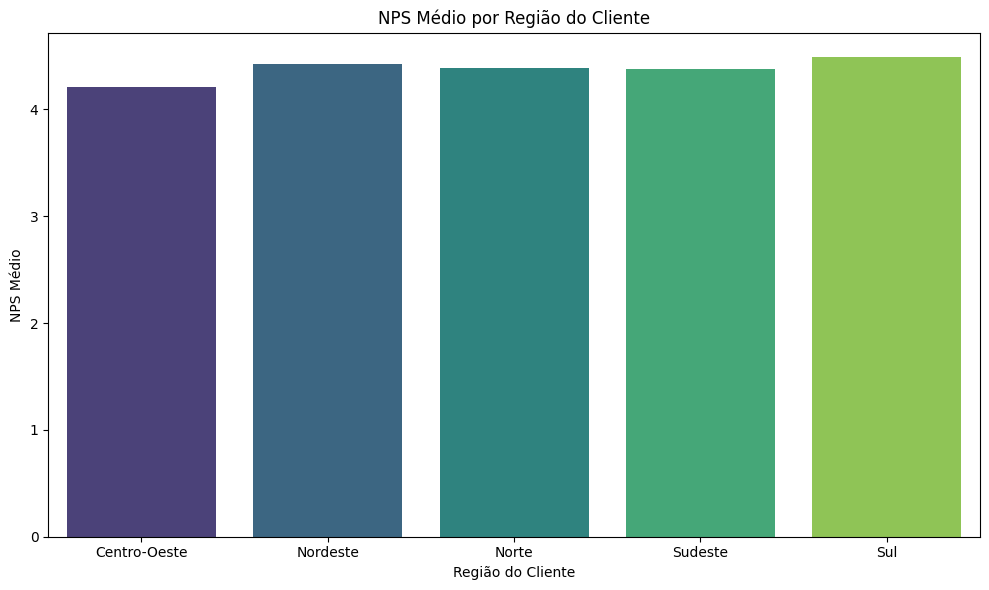

In [28]:
# Visualização comparando o NPS médio por região do cliente
nps_by_region = df_full_nps.groupby('customer_region')['nps_score'].mean().reset_index()
print("NPS Médio por Região do Cliente:")
print(nps_by_region)

plt.figure(figsize=(10, 6))
sns.barplot(data=nps_by_region, x='customer_region', y='nps_score', palette='viridis')
plt.title('NPS Médio por Região do Cliente')
plt.xlabel('Região do Cliente')
plt.ylabel('NPS Médio')
plt.tight_layout()
plt.show()

/tmp/ipykernel_87802/1733141442.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_full_nps, x='customer_region', y='delivery_delay_days', palette='Set2')


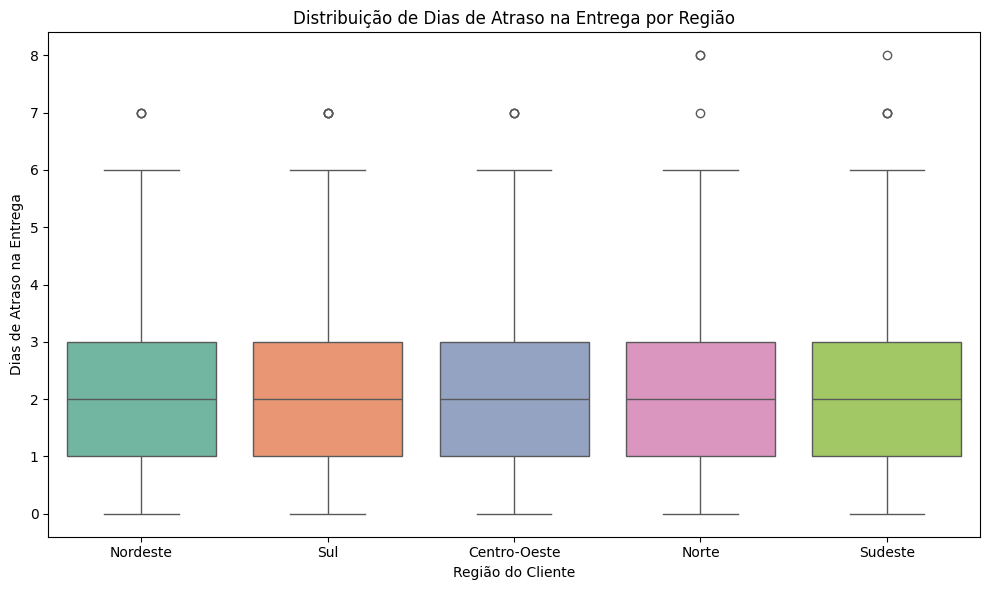

In [29]:
# Visualização comparando dias de atraso na entrega com a região da compra
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_full_nps, x='customer_region', y='delivery_delay_days', palette='Set2')
plt.title('Distribuição de Dias de Atraso na Entrega por Região')
plt.xlabel('Região do Cliente')
plt.ylabel('Dias de Atraso na Entrega')
plt.tight_layout()
plt.show()

/tmp/ipykernel_87802/2518317753.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=faturamento_por_perfil, x='profile_nps', y='order_value', palette=colors)


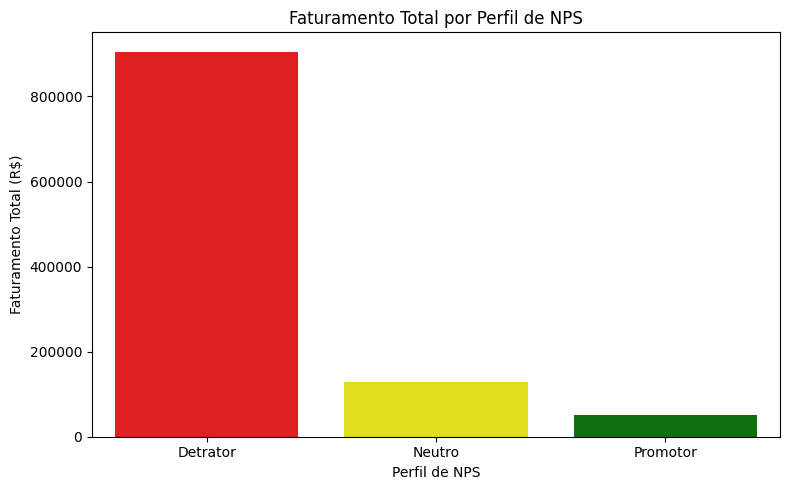

In [ ]:
# Visualização comparando o faturamento total por perfil de NPS
faturamento_por_perfil = df_full_nps.groupby('profile_nps')['order_value'].sum().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=faturamento_por_perfil, x='profile_nps', y='order_value', palette=colors)
plt.title('Faturamento Total por Perfil de NPS')
plt.xlabel('Perfil de NPS')
plt.ylabel('Faturamento Total (R$)')
plt.tight_layout()
plt.show()

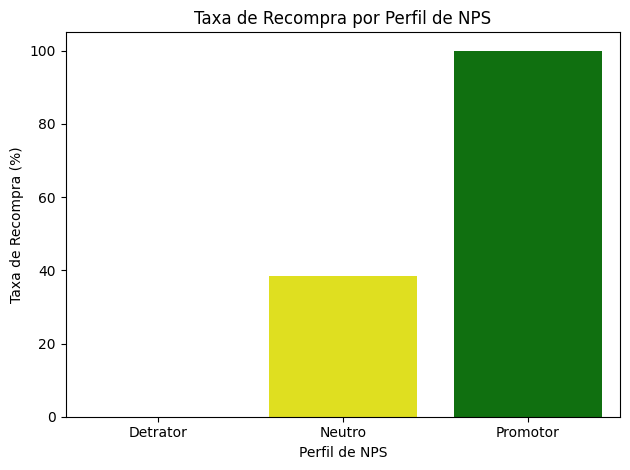

In [27]:
# Visualização comparando a taxa de recompra por perfil de NPS
colors = {'Detrator': 'red', 'Neutro': 'yellow', 'Promotor': 'green'}
sns.barplot(data=df_plot, x='profile_nps', y='taxa_recompra_percent', hue='profile_nps', palette=colors, legend=False)
plt.title('Taxa de Recompra por Perfil de NPS')
plt.xlabel('Perfil de NPS')
plt.ylabel('Taxa de Recompra (%)')
plt.tight_layout()
plt.show()

Principais Descobertas da Análise de Dados
Qualidade dos Dados: O conjunto de dados contém 2.500 linhas e 19 colunas, sem valores ausentes, garantindo uma base sólida para a análise.

Características dos Perfis de NPS:
Detratores (NPS ≤ 6): Representam o maior grupo (2.109 clientes). Apresentam 0% de taxa de recompra, o maior atraso médio na entrega (2,41 dias), o maior número de contatos com o atendimento (1,63), o maior tempo médio de resolução (5,69 dias) e o menor CSAT interno (2,54). Eles também geram o maior volume de reclamações (9.369).

Neutros (7 ≤ NPS ≤ 8): Composto por 281 clientes com uma taxa de recompra de 38,43%. Apresentam atrasos de entrega moderados (1,05 dias), contatos de atendimento (1,01), tempos de resolução e pontuações de CSAT interno medianos, gerando 757 reclamações.

Promotores (NPS ≥ 9): O menor grupo (110 clientes), demonstrando 100% de taxa de recompra, o menor atraso médio na entrega (0,72 dias), menos contatos com o atendimento (0,67), tempos de resolução mais eficientes (3,70 dias) e o maior CSAT interno (6,04). Geram o menor número de reclamações (250).

Principal Impulsionador do NPS: O atraso na entrega (delivery_delay_days) é o fator de maior correlação negativa com a pontuação de NPS, com um valor de -0,59726. Isso indica que o aumento nos atrasos de entrega reduz significativamente a satisfação do cliente.

Impacto do Atendimento ao Cliente: Os Detratores possuem as maiores médias de contatos e tempos de resolução, enquanto os Promotores possuem as menores, sugerindo que interações mínimas e eficientes com o suporte correlacionam-se a uma maior satisfação.

Alinhamento do CSAT Interno: A pontuação média de CSAT interno correlaciona-se diretamente com os perfis de NPS: os Promotores têm a maior pontuação (6,04), os Neutros estão em uma posição intermediária e os Detratores têm a menor (2,54).

Impacto Regional Limitado: A região do cliente (customer_region) não demonstra impacto significativo nas pontuações médias de NPS, com valores variando entre 4,21 (Centro-Oeste) e 4,49 (Sul). Isso indica que a insatisfação é um problema sistêmico, e não concentrado geograficamente.

Insights ou Próximos Passos
Priorizar a Otimização Logística: Focar esforços na redução significativa dos dias de atraso na entrega para melhorar o NPS geral, visto que este é o fator mais crítico que influencia a satisfação do cliente.

Segmentação Estratégica de Clientes: Implementar estratégias direcionadas para cada segmento de NPS, como retenção proativa para Detratores, táticas de conversão para Neutros (que mostram potencial para recompra) e engajamento contínuo para Promotores.